In [1]:
%load_ext autoreload
%autoreload 2

### Replicating Note segmentation

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import soundfile as sf
import matplotlib.pyplot as plt
import librosa

### Extract f0

In [ ]:
from pesto_tracker import PESTOTracker
confidence_threshold=0.5
step_size=0.002902
sample_rate = 44100
use_gpu=False
tracker = PESTOTracker(
            confidence_threshold=confidence_threshold,
            step_size=step_size,
            sample_rate=sample_rate,
            use_gpu=use_gpu,
        )

final_pitches, timesteps, confidence = tracker.extract_f0(audio_path="/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/SourceSeparation/demucs_output/01_GabrielMoreno_YoNoTeHeDaoMotivos/voice.wav")

(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 array([0.0000000e+00, 2.9024899e-03, 5.8049797e-03, ..., 2.4883517e+02,
        2.4883809e+02, 2.4884099e+02], dtype=float32),
 array([0.06785158, 0.05900304, 0.05506543, ..., 0.10895497, 0.10895497,
        0.10895497], dtype=float32))

## Load data for one Track (`ref_file`)

In [3]:
ref_file = Path("01_GabrielMoreno_YoNoTeHeDaoMotivos")

gt_folder = Path("../data/cante2midi_groundTruth")
f0auto_folder = Path("../data/cante2midi_f0")
bark_bands_folder = Path("../data/cante2midi_bakbands")
audio_folder = Path("../data/cante2midiaudio")
spec_folder = Path("../data/cante2midi_spectrum")
PESTO_f0_folder = Path("f0Contour_voice_PESTO")

wav, sr = sf.read(str(audio_folder/ref_file.with_suffix(".wav")))
print(f"Audio loaded ! Samples = {len(wav)}    Dur = {(len(wav)/sr):.2f} sec. (sf={sr})")

f0_contour = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names = ['time', 'f0'])
bark_bands = pd.read_csv(bark_bands_folder/ref_file.with_suffix(".barkbands.csv"),
                         sep=" ",
                         names= [0.0, 50.0, 100.0, 150.0, 200.0, 300.0, 400.0, 510.0, 630.0, 770.0, 920.0, 1080.0, 1270.0, 1480.0, 1720.0, 2000.0, 2320.0, 2700.0, 3150.0, 3700.0, 4400.0, 5300.0, 6400.0, 7700.0, 9500.0, 12000.0, 15500.0, 20500.0, 27000.0])
spec = pd.read_csv(spec_folder/ref_file.with_suffix(".spectrum.csv"),
                   sep=" ",
                   header =None)

pesto_pred = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))

Audio loaded ! Samples = 10973952    Dur = 248.84 sec. (sf=44100)


In [4]:
print(len(f0_contour))
print(len(pesto_pred))

85746
85735


In [ ]:
pesto_pred[90:100]

,time_sec,f0_hz,confidence
90,0.261224,0.0,0.061879
91,0.264127,0.0,0.057937
92,0.267029,0.0,0.053003
93,0.269932,0.0,0.051660
94,0.272834,0.0,0.050901
95,0.275737,0.0,0.052744
96,0.278639,0.0,0.053200
97,0.281542,0.0,0.052743
98,0.284444,0.0,0.046517
99,0.287346,0.0,0.043377


In [6]:
f0_contour[90:100]

,time,f0
90,0.284444,-220.0
91,0.287347,-220.0
92,0.290249,-220.0
93,0.293152,-220.0
94,0.296054,-220.0
95,0.298957,-220.0
96,0.301859,-220.0
97,0.304762,-220.0
98,0.307664,-220.0
99,0.310567,-220.0


In [7]:
# split columns
time = spec.iloc[:,0]
magnitudes = spec.iloc[:,1:514]   # shape: (frames, bins)

print(magnitudes.shape)


sample_rate = 44100
fft_size = 1024

bins = magnitudes.shape[1]

freqs = np.arange(bins) * sample_rate / fft_size
magnitudes_db = 20 * np.log10(magnitudes + 1e-10)

(21435, 513)


In [8]:
# remove unvoiced frames
f0_plot = f0_contour.copy()
f0_plot.loc[f0_plot.f0 <= 0, "f0"] = np.nan
f0PESTO_plot = pesto_pred.copy()
f0PESTO_plot.loc[f0PESTO_plot.f0_hz <= 0, "f0_hz"] = np.nan

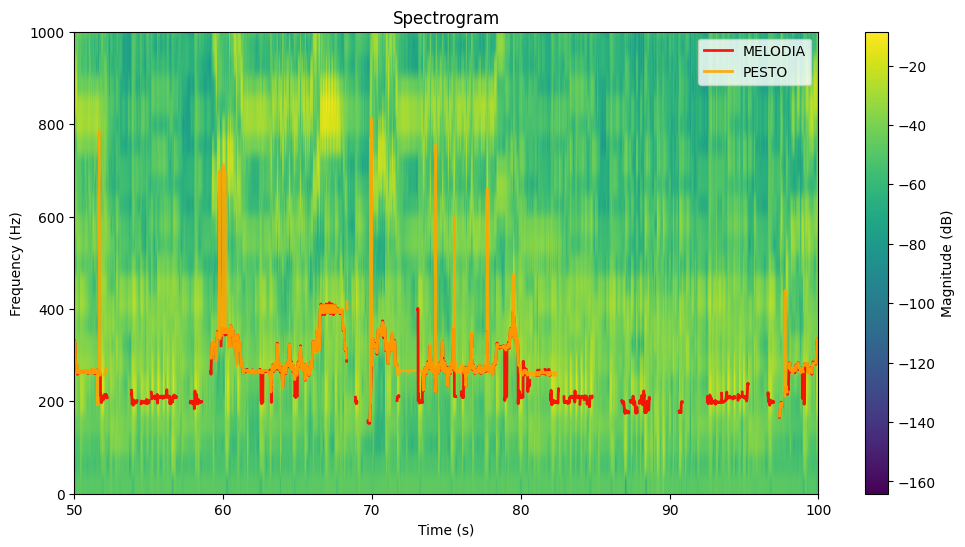

In [9]:
plt.figure(figsize=(12,6))

max_freq = 5000
max_bin = int(max_freq * fft_size / sample_rate)

plt.imshow(
    magnitudes_db.iloc[:,:max_bin].T,
    aspect='auto',
    origin='lower',
    extent=[time.min(), time.max(), freqs.min(), max_freq]
)
plt.plot(f0_plot.time, f0_plot.f0, color="red", linewidth=2, label="MELODIA", alpha=0.9)
plt.plot(f0PESTO_plot.time_sec, f0PESTO_plot.f0_hz, color="orange", linewidth=2, label="PESTO", alpha=0.9)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram")
plt.colorbar(label="Magnitude (dB)")
plt.ylim(0, 1000)
plt.xlim(50, 100)
plt.legend()

plt.show()

In [13]:
pesto_pred[:20010][pesto_pred[:20010].f0_hz>0]

,time_sec,f0_hz,confidence
4679,13.580750,152.596924,0.555421
4680,13.583652,152.596924,0.597804
4681,13.586555,155.562256,0.610556
4682,13.589458,155.563492,0.586561
4683,13.592360,155.563492,0.531690
...,...,...,...
17960,52.128517,271.896790,0.697712
17961,52.131416,271.896851,0.712229
17962,52.134319,271.896790,0.690534
17963,52.137222,271.896790,0.638352


## Melody extraction with MELODIA

In [4]:
import essentia
import essentia.standard as es
import numpy as np

# Load audio
loader = es.MonoLoader(filename=str(audio_folder/ref_file.with_suffix(".wav")), sampleRate=44100)
audio = loader()


# Create pitch extractor
pitch_extractor = es.MultiPitchMelodia(
    sampleRate=44100,
    frameSize=1024,
    hopSize=128,
    minFrequency=120,
    maxFrequency=720,
    #v=0.2,
)

# Run algorithm
pitches = pitch_extractor(audio)   # vector<vector<float>>

pitches = np.array(pitches, dtype=object)

# Time axis
hop_size = 128
sr = 44100
times = np.arange(len(pitches)) * hop_size / sr

print("Frames:", len(pitches))
print("Example frame:", pitches[0])

pitch_trace = np.array([
    frame[0] if len(frame) > 0 else 0
    for frame in pitches
])


melodia_trace = pd.DataFrame({
    "time": times,
    "pitch_hz": pitch_trace
})

melodia_trace.loc[melodia_trace.pitch_hz <= 0, "pitch_hz"] = np.nan

#melodia_trace.to_csv("pitch_trace.csv", index=False)


[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


Frames: 36847
Example frame: [0.]


In [5]:
melodia_trace

,time,pitch_hz
0,0.000000,NaN
1,0.002902,NaN
2,0.005805,NaN
3,0.008707,NaN
4,0.011610,NaN
...,...,...
36842,106.933696,NaN
36843,106.936599,NaN
36844,106.939501,NaN
36845,106.942404,NaN


/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


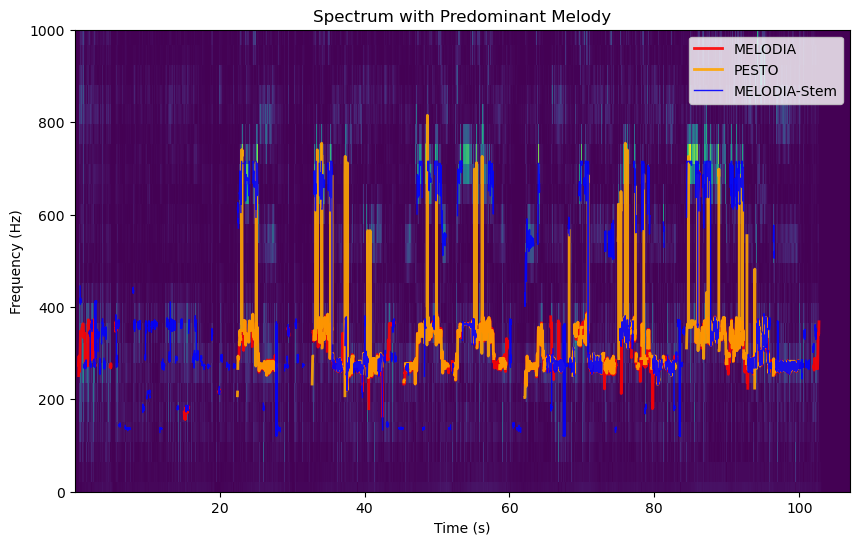

In [6]:
# first column is time
spec_time = spec.iloc[:,0].values
spec_mag = spec.iloc[:,1:].values

# frequency axis
sr = 44100
n_fft = 1024
freqs = np.linspace(0, sr/2, spec_mag.shape[1])

plt.figure(figsize=(10,6))

# spectrogram
plt.pcolormesh(spec_time, freqs, spec_mag.T, shading="auto")

# remove unvoiced frames
f0_plot = f0_contour.copy()
f0_plot.loc[f0_plot.f0 <= 0, "f0"] = np.nan
f0PESTO_plot = pesto_pred.copy()
f0PESTO_plot.loc[f0PESTO_plot.f0_hz<= 0, "f0_hz"] = np.nan

# overlay melody
plt.plot(f0_plot.time, f0_plot.f0, color="red", linewidth=2, label="MELODIA", alpha = 0.9)

plt.plot(f0PESTO_plot.time_sec, f0PESTO_plot.f0_hz, color="orange", linewidth=2, label ="PESTO", alpha=0.9)
plt.plot(melodia_trace.time, melodia_trace.pitch_hz, color="blue", linewidth=1, label ="MELODIA-Stem", alpha=0.9)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrum with Predominant Melody")
plt.ylim(0,1000)
plt.legend()
plt.show()

## Onset Detection

### Interval Onsets 

In [7]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'f0'}, inplace=True)
f0

f0 = f0_contour.copy()

In [8]:
import numpy as np

f_ref = 440
f0_valid = f0.copy()
f0_valid.loc[f0_valid.f0 <= 0, "f0"] = np.nan
cents = 1200 * np.log2(f0_valid.f0 / f_ref)


In [9]:
voiced = ~np.isnan(cents)

segments = []
current = []

for i,v in enumerate(voiced):
    if v:
        current.append(i)
    else:
        if current:
            segments.append(current)
            current = []

if current:
    segments.append(current)


In [10]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(cents)


In [11]:
interval_onsets = []

for i in range(len(peaks)-1):

    p1 = peaks[i]
    p2 = peaks[i+1]

    pitch_diff = abs(cents.iloc[p2] - cents.iloc[p1])
    time_diff = f0.time.iloc[p2] - f0.time.iloc[p1]

    if pitch_diff > 80 and time_diff < 0.25:

        onset = (p1 + p2) // 2
        interval_onsets.append(onset)

In [12]:
onset_times = f0.time.iloc[interval_onsets].values

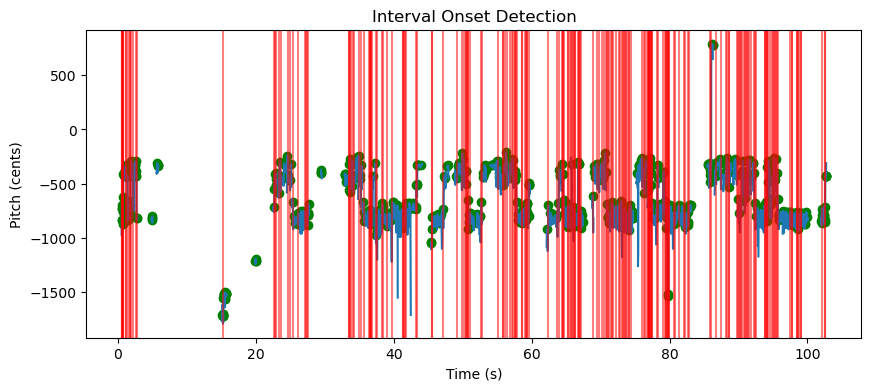

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(f0.time, cents)

plt.scatter(f0.time.iloc[peaks], cents.iloc[peaks], color="green")

for o in interval_onsets:
    plt.axvline(f0.time.iloc[o], color="red", alpha=0.5)

plt.ylabel("Pitch (cents)")
plt.xlabel("Time (s)")
plt.title("Interval Onset Detection")
plt.show()

### Gaussian Onsets

In [ ]:
hop = 128
sr = 44100

dt = hop / sr          # seconds per frame
sigma_s = 0.0435       # 43.5 ms
sigma = sigma_s / dt   # sigma in frames

filter_len_s = 0.3
Nh = int(filter_len_s / dt)
n = np.arange(-Nh//2, Nh//2)
h = -(n / sigma**2) * np.exp(-(n**2) / (2*sigma**2))

from scipy.signal import convolve

cF = convolve(cents, h, mode="same")
from scipy.signal import find_peaks

abs_cf = np.abs(cF)

peaks, _ = find_peaks(abs_cf, height=4.0)
gaussian_onsets = peaks
onset_times = f0.time.iloc[gaussian_onsets].values

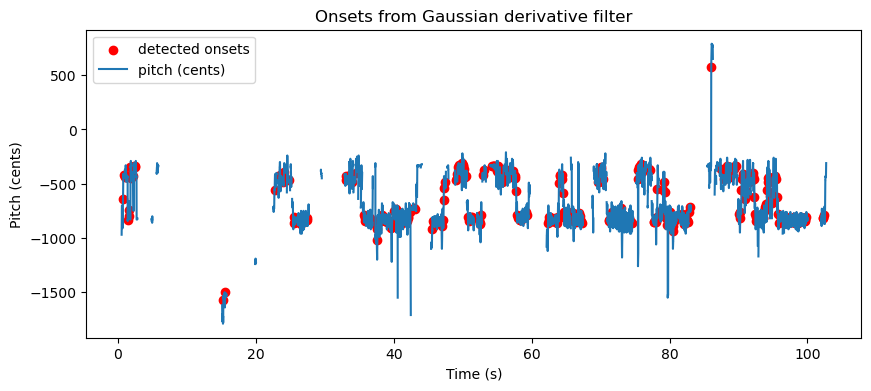

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[gaussian_onsets],
            cents.iloc[gaussian_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

### Volume onsets

In [18]:
import librosa
import numpy as np

y, sr = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=44100)

rms = librosa.feature.rms(
    y=y,
    frame_length=4096,
    hop_length=128
)[0]

In [19]:
import pandas as pd

rms_series = pd.Series(rms)

local_mean = rms_series.rolling(
    window=101,
    center=True
).mean()

rLOC = 20 * np.log10(rms_series / local_mean)

from scipy.signal import find_peaks

volume_onsets, _ = find_peaks(
    -rLOC,
    height=10
)

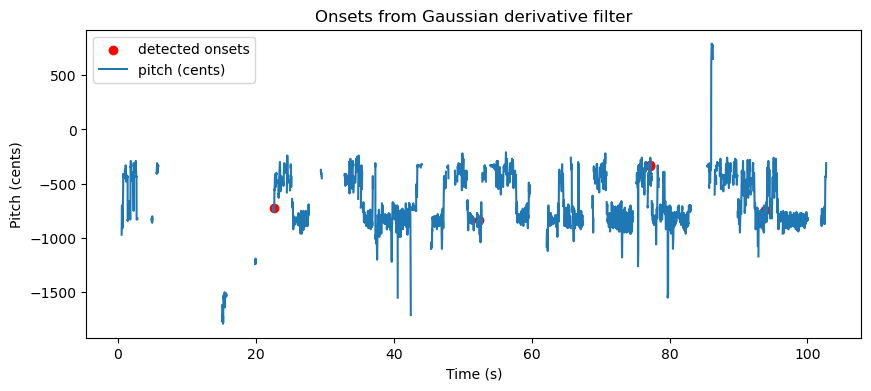

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[volume_onsets],
            cents.iloc[volume_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

### pitch drop onsets

In [21]:
c = cents.values

mu = np.nanmean(c)
sigma = np.nanstd(c)

z = (c - mu) / sigma

pitch_drop_onsets, _ = find_peaks(
    -z,
    height=2
)



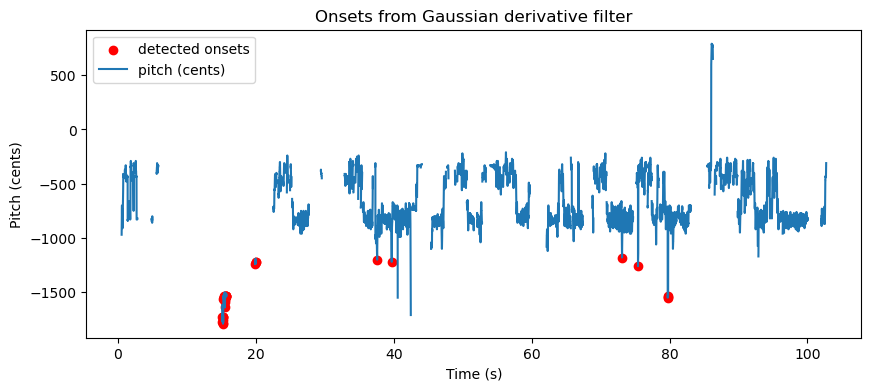

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[pitch_drop_onsets],
            cents.iloc[pitch_drop_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

## All onsets

In [23]:
all_onsets = np.sort(np.concatenate([
    interval_onsets,
    gaussian_onsets,
    volume_onsets,
    pitch_drop_onsets
]))


merge_tol = int(0.05 / dt)  # frames

merged = [all_onsets[0]]

for o in all_onsets[1:]:
    
    if o - merged[-1] <= merge_tol:
        # same onset cluster → keep earliest
        continue
    
    merged.append(o)

merged_onsets = np.array(merged)

onset_times = f0.time.iloc[merged_onsets].values

Text(0.5, 1.0, 'Onsets from All the strategies')

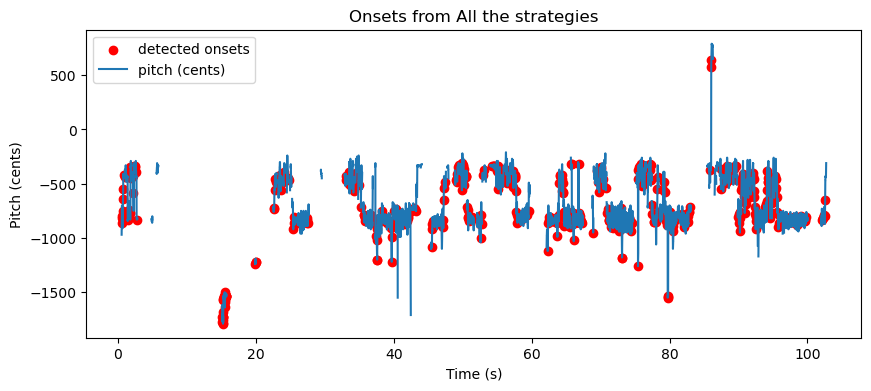

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[all_onsets],
            cents.iloc[all_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from All the strategies")

## Vocal Extraction

In [5]:
import matplotlib.pyplot as plt
from vocal_pitch_extraction import extract_vocal_pitch
import numpy as np

In [6]:
rng = np.random.default_rng(42)
fs = 44100
hop_size = 128
duration_s = 15.0
n_samples = int(duration_s * fs)
n_frames  = int(duration_s * fs / hop_size)

# --- simulate stereo audio: vocals stronger in left channel ---
t = np.arange(n_samples) / fs
# vocal sections: 0-4s, 7-11s, 13-15s
vocal_mask_audio = (
    ((t >= 0)  & (t < 4)) |
    ((t >= 7)  & (t < 11)) |
    ((t >= 13) & (t < 15))
)
vocal_signal = np.where(vocal_mask_audio,
                        np.sin(2 * np.pi * 300 * t) * 0.8, 0.0)
guitar_signal = np.sin(2 * np.pi * 200 * t) * 0.3

left  = vocal_signal + guitar_signal * 0.2 + rng.normal(0, 0.01, n_samples)
right = guitar_signal              + rng.normal(0, 0.01, n_samples)
audio = np.stack([left, right], axis=1)

# --- simulate bark bands (12 bands) ---
# vocal sections have more energy in upper bands
frame_times = np.arange(n_frames) * hop_size / fs
vocal_frame_mask = (
    ((frame_times >= 0)  & (frame_times < 4)) |
    ((frame_times >= 7)  & (frame_times < 11)) |
    ((frame_times >= 13) & (frame_times < 15))
)

bark_bands = rng.uniform(0.0, 0.1, (n_frames, 12))
bark_bands[vocal_frame_mask,  6:] += 0.5   # vocal: more energy in upper bands
bark_bands[~vocal_frame_mask, :6] += 0.5   # guitar: more energy in lower bands

# --- simulate f0 (precomputed) ---
f0_hz = np.zeros(n_frames)
vocal_freq = 300.0
guitar_freq = 200.0
f0_hz[vocal_frame_mask]  = vocal_freq  * (1 + 0.004 * np.sin(2 * np.pi * 5 * frame_times[vocal_frame_mask]))
f0_hz[~vocal_frame_mask] = guitar_freq * (1 + 0.003 * np.sin(2 * np.pi * 3 * frame_times[~vocal_frame_mask]))

# --- run pipeline ---
f0_vocal, v, channel = extract_vocal_pitch(
    audio=audio,
    bark_bands=bark_bands,
    fs=fs,
    hop_size=hop_size,
    f0_hz_precomputed=f0_hz,
    moving_avg_s=1.0,
)

print(f"Selected channel: {'left' if channel == 0 else 'right' if channel == 1 else 'mono'}")
print(f"Frames total:  {n_frames}")
print(f"Frames vocal (ground truth): {vocal_frame_mask.sum()}")
print(f"Frames vocal (predicted):    {v.sum()}")
print(f"Frames with f0 after filtering: {(f0_vocal > 0).sum()}")

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(frame_times, f0_hz, lw=0.7, color="gray", label="raw f0")
axes[0].plot(frame_times, np.where(f0_vocal > 0, f0_vocal, np.nan),
                lw=1.2, color="red", label="vocal f0")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Vocal Pitch Extraction (Section II.A)")
axes[0].legend(fontsize=8)

axes[1].imshow(bark_bands.T, aspect="auto", origin="lower",
                extent=[0, duration_s, 0, 12])
axes[1].set_ylabel("Bark band")
axes[1].set_title("Bark band energies")

axes[2].fill_between(frame_times, vocal_frame_mask.astype(float),
                        alpha=0.4, color="green", label="ground truth vocal")
axes[2].plot(frame_times, v, lw=1.2, color="red", label="predicted vocal")
axes[2].set_ylabel("Vocal mask")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Vocal / non-vocal classification")
axes[2].legend(fontsize=8)

plt.tight_layout()


AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [11]:
import numpy as np
import pandas as pd
import librosa

# 1. Constants
fs = 44100
hop_size = 128

# 2. Load Audio
y, _ = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=fs, mono=False)

# 3. Load F0 (Extracting the values into a 1D NumPy array)
# Assuming the CSV has time in col 0 and frequency in col 1
f0_df = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names=['time', 'f0_hz'])
#f0_df = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))

my_f0 = f0_df['f0_hz'].to_numpy()


bark_bands = pd.read_csv(bark_bands_folder/ref_file.with_suffix(".barkbands.csv"),
                         sep=" ",
                         names= [0.0, 50.0, 100.0, 150.0, 200.0, 300.0, 400.0, 510.0, 630.0, 770.0, 920.0, 1080.0, 1270.0, 1480.0, 1720.0, 2000.0, 2320.0, 2700.0, 3150.0, 3700.0, 4400.0, 5300.0, 6400.0, 7700.0, 9500.0, 12000.0, 15500.0, 20500.0, 27000.0])
bark_bands=bark_bands[bark_bands.columns[:12]]

bark_bands.shape
len(my_f0)

36850

In [12]:
y.shape


(2, 4716288)

/home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/f0est/vocal_pitch_extraction.py:297: UserWarning: Too few unvoiced frames to fit Gaussian; returning raw voicing.
  warnings.warn("Too few unvoiced frames to fit Gaussian; returning raw voicing.")


Selected channel: left
Frames total:  0
Frames vocal (ground truth): 3445
Frames vocal (predicted):    5167
Frames with f0 after filtering: 5167


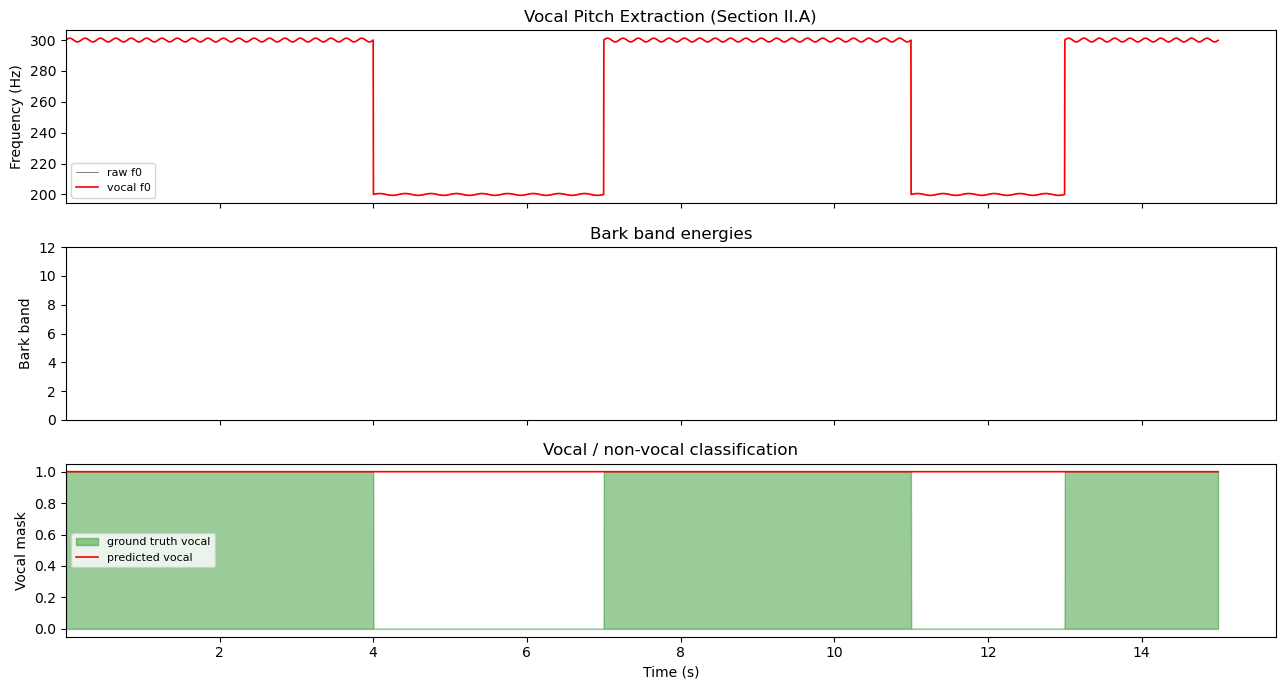

In [13]:
fs = 44100
hop_size = 128
duration_s = len(y) / fs
n_samples = int(duration_s * fs)
n_frames  = int(duration_s * fs / hop_size)




# --- run pipeline ---
f0_vocal, v, channel = extract_vocal_pitch(
    audio=y,
    bark_bands=bark_bands,
    fs=fs,
    hop_size=hop_size,
    f0_hz_precomputed=f0_hz,
    moving_avg_s=1.0,
)

print(f"Selected channel: {'left' if channel == 0 else 'right' if channel == 1 else 'mono'}")
print(f"Frames total:  {n_frames}")
print(f"Frames vocal (ground truth): {vocal_frame_mask.sum()}")
print(f"Frames vocal (predicted):    {v.sum()}")
print(f"Frames with f0 after filtering: {(f0_vocal > 0).sum()}")

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(frame_times, f0_hz, lw=0.7, color="gray", label="raw f0")
axes[0].plot(frame_times, np.where(f0_vocal > 0, f0_vocal, np.nan),
                lw=1.2, color="red", label="vocal f0")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Vocal Pitch Extraction (Section II.A)")
axes[0].legend(fontsize=8)

axes[1].imshow(bark_bands.T, aspect="auto", origin="lower",
                extent=[0, duration_s, 0, 12])
axes[1].set_ylabel("Bark band")
axes[1].set_title("Bark band energies")
axes[2].fill_between(frame_times, vocal_frame_mask.astype(float),
                        alpha=0.4, color="green", label="ground truth vocal")
axes[2].plot(frame_times, v, lw=1.2, color="red", label="predicted vocal")
axes[2].set_ylabel("Vocal mask")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Vocal / non-vocal classification")
axes[2].legend(fontsize=8)

plt.tight_layout()


In [ ]:
f0_vocal, v, channel = extract_vocal_pitch(
    audio=your_stereo_wav,       # (n_samples, 2)
    bark_bands=your_bark_bands,  # (n_frames, 12)  at hop_size=128
    fs=44100,
    hop_size=128,
    f0_hz_precomputed=your_f0,   # skip melodia since you have it
)
# f0_vocal then feeds directly into transcribe_notes() from note_transcription.py

## Note Transcritpion

In [2]:
from note_transcription import transcribe_notes, check_and_align_features
import matplotlib.pyplot as plt

import librosa
import numpy as np


In [3]:

################################
# ---- synthetic demo data ----
fs = 44100
hop_size = 128
hop_s = hop_size / fs
duration_s = 10.0
n_frames = int(duration_s / hop_s)

rng = np.random.default_rng(0)

# Simulate a voiced pitch contour: 3 notes with vibrato
f0 = np.zeros(n_frames)
note_freqs = [261.63, 293.66, 329.63]   # C4, D4, E4
note_starts = [int(0.5 / hop_s), int(3.5 / hop_s), int(6.5 / hop_s)]
note_ends   = [int(3.0 / hop_s), int(6.0 / hop_s), int(9.5 / hop_s)]


t = np.arange(n_frames) * hop_s
for freq, s, e in zip(note_freqs, note_starts, note_ends):
    vibrato = 1 + 0.005 * np.sin(2 * np.pi * 5.5 * t[s:e])
    f0[s:e] = freq * vibrato + rng.normal(0, 0.5, e - s)

# Simulate RMS (slight dip at note boundaries)
rms = 0.1 * np.ones(n_frames)
for s in note_starts:
    rms[max(0, s - 3) : s + 3] *= 0.3

# Simulate spectrum (random, used only for chroma)
n_fft = 2048
spectrum = np.abs(rng.normal(0, 0.1, (n_frames, n_fft // 2 + 1)))
for freq, s, e in zip(note_freqs, note_starts, note_ends):
    k = int(round(freq * n_fft / fs))
    spectrum[s:e, k] += 1.0
#########################################


# ---- run transcription ----
notes = transcribe_notes(f0, rms, spectrum, fs=fs, hop_size=hop_size)

In [15]:
import numpy as np
import pandas as pd
import librosa

# 1. Constants
fs = 44100
hop_size = 128

# 2. Load Audio & RMS
y, _ = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=fs)
my_rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=hop_size)[0]

# 3. Load F0 (Extracting the values into a 1D NumPy array)
# Assuming the CSV has time in col 0 and frequency in col 1
f0_df = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names=['time', 'f0_hz'])
#f0_df = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))

my_f0 = f0_df['f0_hz'].to_numpy()

# 4. Load Spectrum
# Your synthetic spectrum was (n_frames, n_bins). 
# Most CSV exports are (n_bins, n_frames) or vice-versa.
spec_df = pd.read_csv(spec_folder/ref_file.with_suffix(".spectrum.csv"), sep=" ", header=None)
my_spec = spec_df.to_numpy()

# CRITICAL STEP: Shape Alignment
# Your synthetic data used shape (n_frames, n_bins). 
# If your CSV is (n_bins, n_frames), transpose it:
if my_spec.shape[0] < my_spec.shape[1]: 
    my_spec = my_spec.T

f0, rms, spectrum = check_and_align_features(
    f0_hz=my_f0,          rms=my_rms,         spectrum=my_spec,
    f0_hop=128,           rms_hop=128,         spectrum_hop=512,
    target_hop=128,       fs=44100,
)

Input durations:  f0=248.877s  rms=248.845s  spec=248.860s
After alignment:  all 85735 frames = 248.845s @ hop=128


In [16]:
# 5. Length Synchronization
# Different tools often result in slightly different frame counts (+/- 1 or 2 frames).
# We truncate everything to the shortest common length to prevent IndexErrors.
min_len = min(len(f0), len(rms), spectrum.shape[0])
f0 = f0[:min_len]
rms = rms[:min_len]
spectrum = spectrum[:min_len, :]
# ---- run transcription ----
notes = transcribe_notes(f0, rms, spectrum, fs=fs, hop_size=hop_size)

Transcribed notes:
 Onset (s)   Duration (s)   MIDI  Note name
    22.442          0.087     56        G#3
    22.529          0.093     62         D4
    22.500          0.070     62         D4
    22.750          0.116     66        F#4
    22.866          0.075     64         E4
    23.017          0.093     66        F#4
    23.110          0.113     66        F#4
    23.232          0.084     66        F#4
    23.316          0.096     66        F#4
    23.391          0.061     66        F#4
    23.452          0.087     66        F#4
    23.539          0.096     64         E4
    23.635          0.096     66        F#4
    23.731          0.215     66        F#4
    23.946          0.119     64         E4
    24.065          0.131     66        F#4
    24.195          0.075     66        F#4
    24.570          0.070     66        F#4
    24.639          0.096     66        F#4
    24.735          0.180     66        F#4
    24.915          0.093     63        D#4
    25.008   

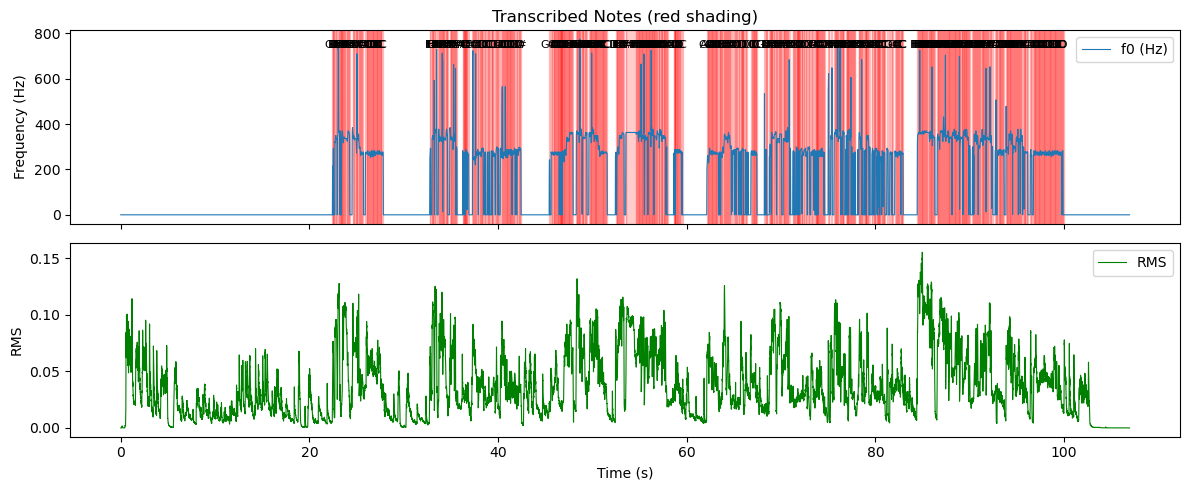

In [8]:
# ---- synthetic demo data ----
fs = 44100
hop_size = 128
hop_s = hop_size / fs
duration_s = len(y) / fs
n_frames = int(duration_s / hop_s)-1

print("Transcribed notes:")
print(f"{'Onset (s)':>10}  {'Duration (s)':>13}  {'MIDI':>5}  {'Note name':>9}")
note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
for n in notes:
    name = note_names[n.midi % 12] + str(n.midi // 12 - 1)
    print(f"{n.onset:>10.3f}  {n.duration:>13.3f}  {n.midi:>5}  {name:>9}")

# ---- plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_frames = np.arange(n_frames) * hop_s

axes[0].plot(t_frames, f0, lw=0.8, label="f0 (Hz)")
for note in notes:
    axes[0].axvspan(note.onset, note.onset + note.duration, alpha=0.2, color="red")
    axes[0].text(note.onset + note.duration / 2, max(f0) * 0.95,
                    note_names[note.midi % 12], ha="center", fontsize=8)
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Transcribed Notes (red shading)")
axes[0].legend()

axes[1].plot(t_frames, rms, lw=0.8, color="green", label="RMS")
axes[1].set_ylabel("RMS")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/note_transcription_demo.png", dpi=150)
#print("\nPlot saved to note_transcription_demo.png")


In [17]:
import csv

# Output CSV file path
csv_path = Path("output_MELODIA.notes.csv")

# Write CSV
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    for note in notes:
        # Convert onset and duration to float and format if needed
        writer.writerow([float(note.onset), float(note.duration), int(note.midi)])

print(f"Saved {len(notes)} notes to {csv_path}")

Saved 1237 notes to output_MELODIA.notes.csv


#### Onsets to notes

In [38]:
onsets = np.sort(all_onsets)

notes = []

for i in range(len(onsets)-1):

    start = onsets[i]
    end = onsets[i+1]

    segment = cents[start:end]

    segment = segment[~np.isnan(segment)]

    if len(segment) == 0:
        continue

    pitch = np.median(segment)
    hist, bins = np.histogram(segment, bins=120)
    pitch = bins[np.argmax(hist)]

    notes.append({
        "onset": f0.time.iloc[start],
        "duration": f0.time.iloc[end] - f0.time.iloc[start],
        "pitch_cents": pitch
    })


for note in notes:

    semitone = np.round(note["pitch_cents"] / 100)

    note["pitch_quantized_cents"] = semitone * 100

In [39]:
for note in notes:

    midi = 69 + (note["pitch_quantized_cents"] / 100)

    note["midi"] = int(midi)

In [40]:
merged = [notes[0]]

for n in notes[1:]:

    prev = merged[-1]

    if n["midi"] == prev["midi"]:
        prev["duration"] += n["duration"]
    else:
        merged.append(n)

notes = merged

In [41]:

notes_df = pd.DataFrame(notes)
notes_df.to_csv("testing_transcription_hist.csv")


## Another transcription

In [57]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'f0'}, inplace=True)
f0.head()

f0 = f0_contour.copy()

In [58]:

f_ref = 440
f0_valid = f0.copy()
f0_valid.loc[f0_valid.f0 <= 0, "f0"] = np.nan
cents = 1200 * np.log2(f0_valid.f0 / f_ref)

In [59]:
from scipy.signal import medfilt

win = int(0.1 / dt)   # 100 ms
if win % 2 == 0:
    win += 1

c_smooth = medfilt(cents, win)

semi = c_smooth / 100

pitch_track = np.round(semi)

changes = np.where(np.diff(pitch_track) != 0)[0] + 1

onsets = np.concatenate(([0], changes))

In [61]:
import numpy as np

notes = []

for i in range(len(onsets)-1):
    start = onsets[i]
    end = onsets[i+1]

    # extract the pitch segment
    segment_pitch = pitch_track[start:end]

    # remove unvoiced frames (NaNs)
    voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

    # skip segment if no voiced frames
    if len(voiced_pitch) == 0:
        continue

    # compute a robust estimate of pitch (median works well)
    pitch_median = np.median(voiced_pitch)

    notes.append({
        "onset": f0.time.iloc[start],
        "duration": f0.time.iloc[end] - f0.time.iloc[start],
        "midi": int(round(69 + pitch_median))  # quantized to nearest semitone
    })

In [62]:
min_dur = 0.05  # 80 ms

notes = [n for n in notes if n["duration"] > min_dur]

In [ ]:
notes_df = pd.DataFrame(notes)
notes_df.to_csv("simple_transcription_f0Melodia.csv")

#### Mixed approach

In [81]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, convolve

def detect_interval_onsets(pitch_track, f0_time, delta_pmin=80, max_time_dist=0.25, fs=44100):
    """
    Detect interval onsets using local maxima of pitch contour (vibrato-insensitive)
    pitch_track: cent-scaled pitch track (np.array, NaN for unvoiced)
    f0_time: corresponding times (s)
    """
    # find local maxima
    local_maxima, _ = find_peaks(pitch_track, height=-np.inf)
    interval_onsets = []

    for i in range(len(local_maxima)-1):
        p1, p2 = pitch_track[local_maxima[i]], pitch_track[local_maxima[i+1]]
        dt = f0_time[local_maxima[i+1]] - f0_time[local_maxima[i]]
        if np.abs(p2 - p1) >= delta_pmin and dt <= max_time_dist:
            # onset approx centered between maxima
            onset_idx = int((local_maxima[i] + local_maxima[i+1]) / 2)
            interval_onsets.append(onset_idx)
    
    return interval_onsets

def detect_steady_onsets(pitch_track, audio_rms, N=4096, hop=128, voiced_thresh=-10, zmax=-2):
    """
    Detect steady pitch onsets from volume dips (RMS) and local pitch decreases
    pitch_track: cent-scaled pitch track (NaN for unvoiced)
    audio_rms: RMS array aligned with pitch_track
    """
    steady_onsets = []

    # 1. RMS local decay detection
    half_window = 50
    rLOC = 20 * np.log10(audio_rms / (np.convolve(audio_rms, np.ones(2*half_window+1)/(2*half_window+1), mode='same') + 1e-12))
    rms_dips = np.where(rLOC < voiced_thresh)[0]
    steady_onsets.extend(rms_dips.tolist())

    # 2. Pitch local minima detection (z-score)
    voiced_idx = ~np.isnan(pitch_track)
    if np.any(voiced_idx):
        c_voiced = pitch_track[voiced_idx]
        z = (c_voiced - np.mean(c_voiced)) / np.std(c_voiced)
        pitch_dips = np.where(z < zmax)[0]
        # map back to full index
        all_idx = np.arange(len(pitch_track))[voiced_idx]
        steady_onsets.extend(all_idx[pitch_dips].tolist())

    return list(sorted(set(steady_onsets)))

def gaussian_derivative_peaks(pitch_track, sigma=0.0435, fs=44100, min_peak=4.0):
    """
    Apply first derivative Gaussian to detect subtle pitch changes
    """
    Nc = len(pitch_track)
    N_sigma = int(np.round(6 * sigma * fs))
    n = np.arange(-N_sigma//2, N_sigma//2 + 1)
    h = -n / (sigma**2) * np.exp(-n**2 / (2*sigma**2))

    pitch_voiced = np.nan_to_num(pitch_track, nan=0.0)
    cF = convolve(pitch_voiced, h, mode='same')

    peaks, _ = find_peaks(np.abs(cF), height=min_peak)
    return peaks

def segment_notes(f0_df, audio_rms, fs=44100):
    """
    Full robust note segmentation and pitch quantization
    """
    # Convert f0 to cent scale (assuming reference 440 Hz)
    fRef = 440.0
    c0 = 1200 * np.log2(np.nan_to_num(f0.frequency, nan=fRef) / fRef)

    # 1. Detect all onset candidates
    interval_onsets = detect_interval_onsets(c0, f0.time.to_numpy(), fs=fs)
    steady_onsets = detect_steady_onsets(c0, audio_rms)
    derivative_peaks = gaussian_derivative_peaks(c0, fs=fs)

    # Merge all onsets
    merged_onsets = sorted(list(set(interval_onsets + steady_onsets + derivative_peaks.tolist())))

    # 2. Segment notes between merged onsets
    notes = []
    min_voiced_ratio = 0.5

    for i in range(len(merged_onsets)-1):
        start = merged_onsets[i]
        end = merged_onsets[i+1]
        segment_pitch = c0[start:end]
        voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

        if len(voiced_pitch) == 0:
            continue
        if len(voiced_pitch) / len(segment_pitch) < min_voiced_ratio:
            continue

        pitch_median = np.median(voiced_pitch)

        voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

        if len(voiced_pitch) == 0:
            # Skip this note segment because it's unvoiced
            continue

        pitch_median = np.median(voiced_pitch)
        midi_note = int(round(69 + pitch_median / 100))  # cent -> semitone

        notes.append({
            "onset": f0.time.iloc[start],
            "duration": f0.time.iloc[end] - f0.time.iloc[start],
            "midi": midi_note
})

    return notes

In [85]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'frequency'}, inplace=True)
f0.loc[f0.frequency <= 0, "frequency"] = np.nan
f0.head()


,time,frequency
0,0.00,NaN
1,0.01,NaN
2,0.02,NaN
3,0.03,NaN
4,0.04,NaN


In [87]:
import librosa
import numpy as np

audio, sr = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=44100)

import numpy as np

# audio: 1D numpy array of your waveform
fs = 44100
hop_size = int(0.01 * fs)  # 441 samples for 10 ms hop

num_frames = len(audio) // hop_size
rms = np.zeros(num_frames)

for i in range(num_frames):
    frame = audio[i*hop_size : i*hop_size + hop_size]
    rms[i] = np.sqrt(np.mean(frame**2))

print(len(rms))
notes = segment_notes(f0_df=f0, audio_rms=rms)

min_dur = 0.05  # 80 ms

notes = [n for n in notes if n["duration"] > min_dur]

10694


In [89]:
notes_df = pd.DataFrame(notes)
notes_df.to_csv("mixed_transcription_Pesto.csv")

## `note_transcription.py` function overview

This section is a compact walkthrough of the key functions in `noteTranscription/note_transcription.py`:

1. Helpers (`hz_to_cents`, `voiced_segments`, `check_and_align_features`)
2. Segmentation onset detectors
3. Pitch-labelling functions
4. End-to-end `transcribe_notes` pipeline

All examples below use synthetic data so they can run independently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from note_transcription import (
    hz_to_cents,
    voiced_segments,
    check_and_align_features,
    detect_onsets_local_maxima,
    detect_onsets_gaussian_derivative,
    detect_onsets_volume_dip,
    detect_onsets_pitch_dip,
    merge_and_deduplicate,
    segment_contour,
    estimate_tuning_deviation,
    compute_global_pitch_class_probability,
    compute_local_pitch_probability,
    assign_pitch_label,
    transcribe_notes,
)

fs = 44100
target_hop = 128
hop_s = target_hop / fs
print('Imports ready.')

Imports ready.


In [2]:
# --- Synthetic data for examples ---
rng = np.random.default_rng(0)
duration_s = 8.0
n_frames = int(duration_s / hop_s)

# f0 at 128-hop with voiced/unvoiced regions
f0_128 = np.zeros(n_frames)
note_regions = [
    (0.5, 2.0, 261.63),
    (2.3, 4.0, 293.66),
    (4.4, 6.2, 329.63),
]

for t0, t1, f in note_regions:
    s = int(t0 / hop_s)
    e = int(t1 / hop_s)
    t = np.arange(e - s) * hop_s
    vibrato = 1 + 0.004 * np.sin(2 * np.pi * 5 * t)
    f0_128[s:e] = f * vibrato + rng.normal(0, 0.3, e - s)

# lowlevel + spectrum at 512-hop (to demonstrate check_and_align_features)
ll_hop = 512
sp_hop = 512
ll_hop_s = ll_hop / fs
n_512 = int(duration_s / ll_hop_s)

rms_512 = 0.08 * np.ones(n_512)
for t0, _, _ in note_regions:
    s = int(t0 / ll_hop_s)
    rms_512[max(0, s - 1): min(n_512, s + 2)] *= 0.4
rms_512 += rng.normal(0, 0.002, n_512)
rms_512 = np.maximum(rms_512, 1e-5)

n_bins = 513
spectrum_512 = np.abs(rng.normal(0, 0.01, (n_512, n_bins)))
for t0, t1, f in note_regions:
    s = int(t0 / ll_hop_s)
    e = int(t1 / ll_hop_s)
    k = int(round(f * ((n_bins - 1) * 2) / fs))
    k = np.clip(k, 0, n_bins - 1)
    spectrum_512[s:e, k] += 0.5

print(f'f0_128: {f0_128.shape}, rms_512: {rms_512.shape}, spectrum_512: {spectrum_512.shape}')

f0_128: (2756,), rms_512: (689,), spectrum_512: (689, 513)


Detected voiced segments (frame idx): [(172, 689), (792, 1378), (1515, 2136)]
Input durations:  f0=7.999s  rms=7.999s  spec=7.999s
After alignment:  all 2753 frames = 7.991s @ hop=128
Aligned shapes: (2753,) (2753,) (2753, 513)


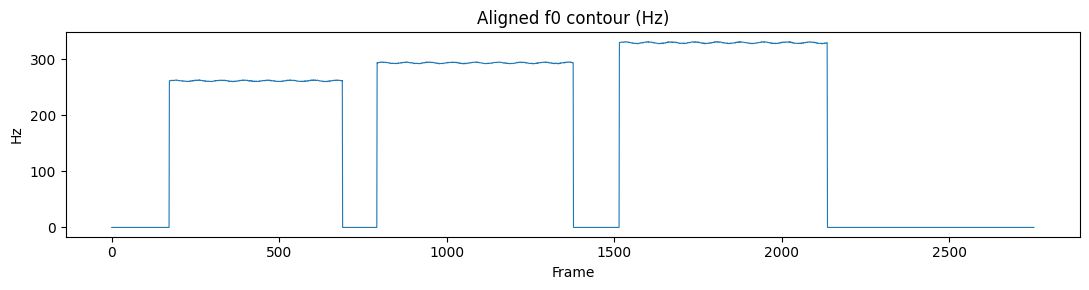

In [3]:
# 1) Helpers: hz_to_cents, voiced_segments, check_and_align_features

cents = hz_to_cents(f0_128)
segments = voiced_segments(f0_128)
print('Detected voiced segments (frame idx):', segments[:5])

f0_aligned, rms_aligned, spec_aligned = check_and_align_features(
    f0_hz=f0_128,
    rms=rms_512,
    spectrum=spectrum_512,
    f0_hop=128,
    rms_hop=512,
    spectrum_hop=512,
    target_hop=128,
    fs=fs,
    verbose=True,
)

print('Aligned shapes:', f0_aligned.shape, rms_aligned.shape, spec_aligned.shape)

plt.figure(figsize=(11, 3))
plt.plot(f0_aligned, lw=0.8)
plt.title('Aligned f0 contour (Hz)')
plt.xlabel('Frame')
plt.ylabel('Hz')
plt.tight_layout()
plt.show()

local_max=0, gauss=48, volume=0, pitch_dip=0
merged onsets=48, note intervals=49


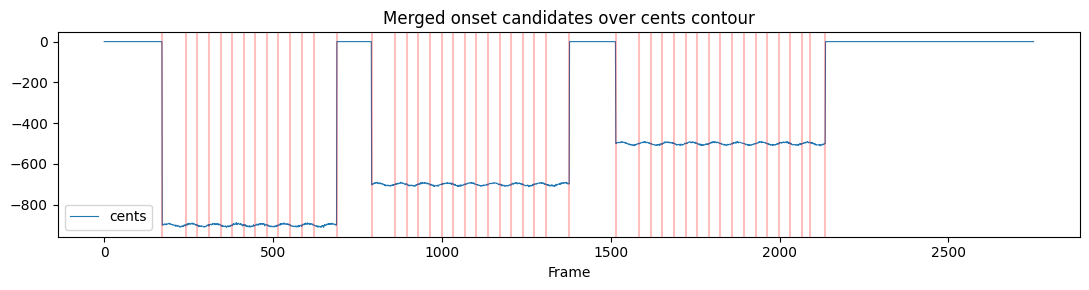

In [4]:
# 2) Segmentation functions overview

cents_aligned = hz_to_cents(f0_aligned)

o1 = detect_onsets_local_maxima(cents_aligned, fs=fs, hop_size=target_hop)
o2 = detect_onsets_gaussian_derivative(cents_aligned, fs=fs, hop_size=target_hop)
o3 = detect_onsets_volume_dip(rms_aligned)
o4 = detect_onsets_pitch_dip(cents_aligned)
onsets = merge_and_deduplicate(o1, o2, o3, o4, min_gap_frames=5)
intervals = segment_contour(
    f0_hz=f0_aligned,
    rms=rms_aligned,
    fs=fs,
    hop_size=target_hop,
)

print(f'local_max={len(o1)}, gauss={len(o2)}, volume={len(o3)}, pitch_dip={len(o4)}')
print(f'merged onsets={len(onsets)}, note intervals={len(intervals)}')

plt.figure(figsize=(11, 3))
plt.plot(cents_aligned, lw=0.8, label='cents')
for x in onsets:
    plt.axvline(x, color='r', alpha=0.25)
plt.title('Merged onset candidates over cents contour')
plt.xlabel('Frame')
plt.legend()
plt.tight_layout()
plt.show()

tuning_cents=0.142
first segment frames=[172, 241) -> predicted MIDI=60


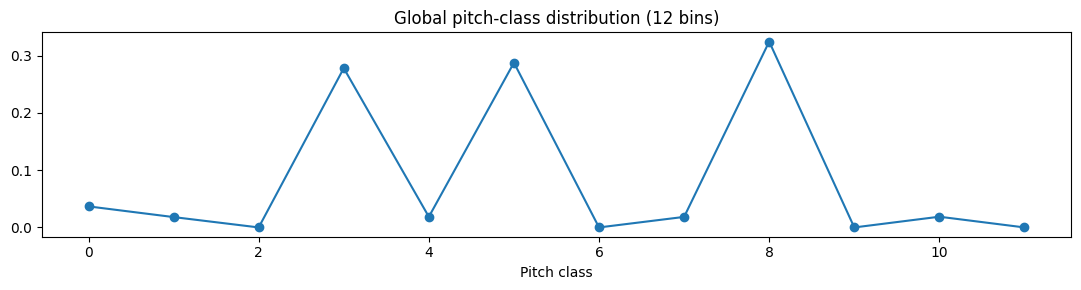

In [5]:
# 3) Pitch-labelling functions overview

tuning_cents = estimate_tuning_deviation(f0_aligned)
L_global = compute_global_pitch_class_probability(
    spectrum=spec_aligned,
    fs=fs,
    hop_size=target_hop,
    tuning_cents=tuning_cents,
)

# Take first segmented note (if any) and inspect local probabilities
if intervals:
    s0, e0 = intervals[0]
    f0_seg = f0_aligned[s0:e0]
    L_local = compute_local_pitch_probability(f0_seg, tuning_cents=tuning_cents)
    midi_label = assign_pitch_label(f0_seg, L_global, tuning_cents=tuning_cents)

    print(f'tuning_cents={tuning_cents:.3f}')
    print(f'first segment frames=[{s0}, {e0}) -> predicted MIDI={midi_label}')

    plt.figure(figsize=(11, 3))
    plt.plot(L_global, marker='o')
    plt.title('Global pitch-class distribution (12 bins)')
    plt.xlabel('Pitch class')
    plt.tight_layout()
    plt.show()
else:
    print('No intervals found in synthetic example.')

Total notes: 46
onset=0.499s, dur=0.200s, midi=60
onset=0.700s, dur=0.099s, midi=60
onset=0.798s, dur=0.102s, midi=60
onset=0.900s, dur=0.102s, midi=60
onset=1.051s, dur=0.148s, midi=60
onset=1.199s, dur=0.102s, midi=60
onset=1.300s, dur=0.099s, midi=60
onset=1.399s, dur=0.099s, midi=60
onset=1.498s, dur=0.102s, midi=60
onset=1.599s, dur=0.102s, midi=60


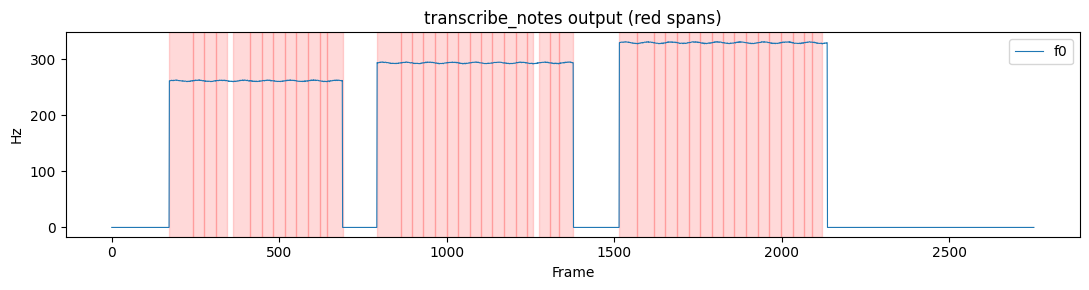

In [6]:
# 4) End-to-end overview: transcribe_notes

notes = transcribe_notes(
    f0_hz=f0_aligned,
    rms=rms_aligned,
    spectrum=spec_aligned,
    fs=fs,
    hop_size=target_hop,
)

print(f'Total notes: {len(notes)}')
for n in notes[:10]:
    print(f'onset={n.onset:.3f}s, dur={n.duration:.3f}s, midi={n.midi}')

# Quick visualization
plt.figure(figsize=(11, 3))
plt.plot(f0_aligned, lw=0.8, label='f0')
for n in notes:
    s = int(n.onset / hop_s)
    e = int((n.onset + n.duration) / hop_s)
    plt.axvspan(s, e, color='red', alpha=0.15)
plt.title('transcribe_notes output (red spans)')
plt.xlabel('Frame')
plt.ylabel('Hz')
plt.legend()
plt.tight_layout()
plt.show()

## Real-data example (no synthetic signals)

This section runs the same workflow on one real track using:

- f0: `f0est/f0Contour_voiceDemucs_PESTO`
- lowlevel: `data/cante2midi_lowlevel`
- spectrum: `data/cante2midi_spectrum`

It mirrors the logic in `noteTranscription/main.py`: load → align → segment helpers → `transcribe_notes`.

In [9]:
from pathlib import Path

# Resolve repo root robustly (works whether cwd is repo root or noteTranscription/)
cwd = Path.cwd()
if (cwd / 'f0est').exists() and (cwd / 'data').exists():
    repo_root = cwd
elif (cwd.parent / 'f0est').exists() and (cwd.parent / 'data').exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(f'Could not infer repo root from cwd={cwd}')

f0_dir = repo_root / 'f0est' / 'f0Contour_voiceDemucs_PESTO'
lowlevel_dir = repo_root / 'data' / 'cante2midi_lowlevel'
spectrum_dir = repo_root / 'data' / 'cante2midi_spectrum'

assert f0_dir.exists(), f'Missing f0 dir: {f0_dir}'
assert lowlevel_dir.exists(), f'Missing lowlevel dir: {lowlevel_dir}'
assert spectrum_dir.exists(), f'Missing spectrum dir: {spectrum_dir}'

# Pick one real track that exists in all 3 folders
f0_files = sorted(f0_dir.glob('*.f0.csv'))
assert f0_files, f'No f0 files in {f0_dir}'

track_id = None
f0_path = None
for p in f0_files:
    tid = p.name.replace('.f0.csv', '')
    ll = lowlevel_dir / f'{tid}.lowlevel.csv'
    sp = spectrum_dir / f'{tid}.spectrum.csv'
    if ll.exists() and sp.exists():
        track_id = tid
        f0_path = p
        lowlevel_path = ll
        spectrum_path = sp
        break

assert track_id is not None, 'No matching real track found across f0/lowlevel/spectrum.'

print('Selected track:', track_id)
print('f0:', f0_path)
print('lowlevel:', lowlevel_path)
print('spectrum:', spectrum_path)

# --- Loaders equivalent to noteTranscription/main.py ---
def load_f0_any(path: Path) -> np.ndarray:
    first_line = path.open('r', encoding='utf-8').readline().strip().lower()
    has_header = any(ch.isalpha() for ch in first_line)

    if has_header:
        data = np.genfromtxt(path, delimiter=',', names=True, dtype=float)
        if 'f0_hz' in (data.dtype.names or ()):
            return np.asarray(data['f0_hz'], dtype=float)
        if data.dtype.names and len(data.dtype.names) >= 2:
            return np.asarray(data[data.dtype.names[1]], dtype=float)
        raise ValueError(f'Could not parse headered f0 CSV: {path}')

    data = np.loadtxt(path, delimiter=',')
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 1].astype(float)


def load_lowlevel_rms(path: Path) -> np.ndarray:
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 6].astype(float)  # RMS column


def load_spectrum_mag(path: Path) -> np.ndarray:
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data[:, 1:].astype(float)  # skip time

f0_real = load_f0_any(f0_path)
rms_real = load_lowlevel_rms(lowlevel_path)
spec_real = load_spectrum_mag(spectrum_path)

# Align to target hop (same as main.py defaults)
f0_real, rms_real, spec_real = check_and_align_features(
    f0_hz=f0_real,
    rms=rms_real,
    spectrum=spec_real,
    f0_hop=128,
    rms_hop=512,
    spectrum_hop=512,
    target_hop=128,
    fs=44100,
    verbose=True,
)

print('Aligned shapes:', f0_real.shape, rms_real.shape, spec_real.shape)

Selected track: 01_GabrielMoreno_YoNoTeHeDaoMotivos
f0: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/f0est/f0Contour_voiceDemucs_PESTO/01_GabrielMoreno_YoNoTeHeDaoMotivos.f0.csv
lowlevel: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/data/cante2midi_lowlevel/01_GabrielMoreno_YoNoTeHeDaoMotivos.lowlevel.csv
spectrum: /home/ibroto/Documents/UPF_SMC/MIR/flamenco-mir/data/cante2midi_spectrum/01_GabrielMoreno_YoNoTeHeDaoMotivos.spectrum.csv
Input durations:  f0=248.845s  rms=248.860s  spec=248.860s
After alignment:  all 85735 frames = 248.845s @ hop=128
Aligned shapes: (85735,) (85735,) (85735, 513)


Voiced segments: 211
onset detectors -> local=102, gauss=944, volume=235, pitch_dip=78
Merged onsets: 1280 | Segmented intervals: 983
Estimated tuning deviation: 22.721 cents
Total transcribed notes (real track): 883
First 10 notes:
  onset=16.829s, dur=0.070s, midi=56
  onset=16.898s, dur=0.122s, midi=56
  onset=17.807s, dur=0.084s, midi=56
  onset=17.891s, dur=0.087s, midi=56
  onset=17.850s, dur=0.116s, midi=56
  onset=17.966s, dur=0.078s, midi=56
  onset=18.045s, dur=0.131s, midi=56
  onset=47.296s, dur=0.154s, midi=63
  onset=47.450s, dur=0.180s, midi=63
  onset=47.630s, dur=0.055s, midi=63


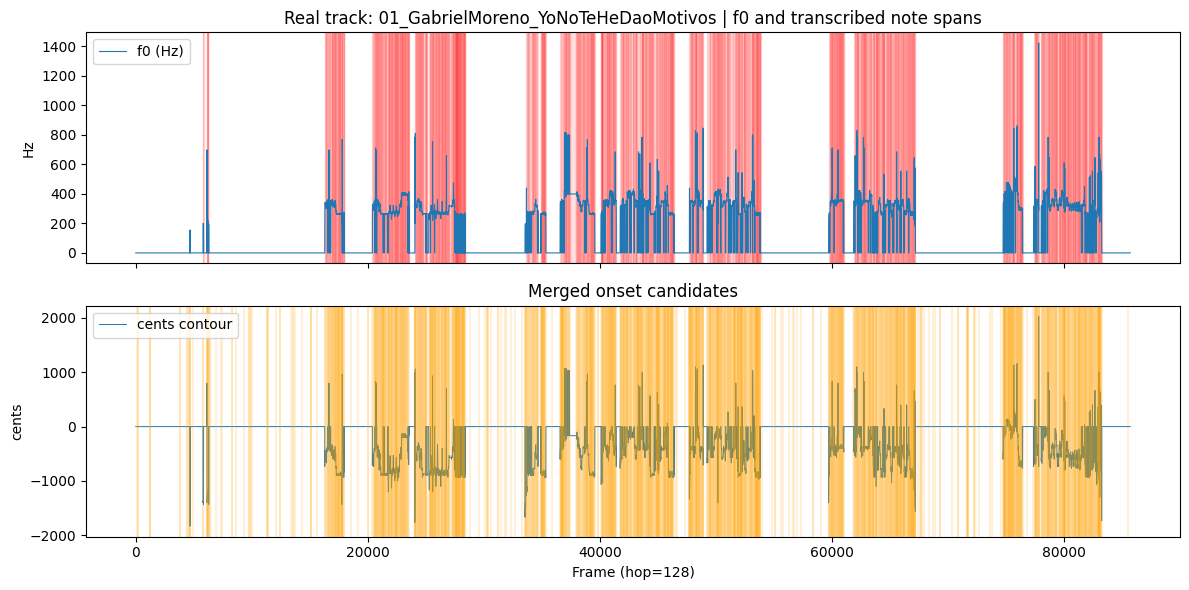

In [10]:
# Run the same function overview on this real track
cents_real = hz_to_cents(f0_real)
segments_real = voiced_segments(f0_real)

o1_real = detect_onsets_local_maxima(cents_real, fs=44100, hop_size=128)
o2_real = detect_onsets_gaussian_derivative(cents_real, fs=44100, hop_size=128)
o3_real = detect_onsets_volume_dip(rms_real)
o4_real = detect_onsets_pitch_dip(cents_real)
onsets_real = merge_and_deduplicate(o1_real, o2_real, o3_real, o4_real, min_gap_frames=5)
intervals_real = segment_contour(f0_real, rms_real, fs=44100, hop_size=128)

print('Voiced segments:', len(segments_real))
print(f'onset detectors -> local={len(o1_real)}, gauss={len(o2_real)}, volume={len(o3_real)}, pitch_dip={len(o4_real)}')
print('Merged onsets:', len(onsets_real), '| Segmented intervals:', len(intervals_real))

# Pitch-model components
tuning_real = estimate_tuning_deviation(f0_real)
L_global_real = compute_global_pitch_class_probability(spec_real, fs=44100, hop_size=128, tuning_cents=tuning_real)
print(f'Estimated tuning deviation: {tuning_real:.3f} cents')

# End-to-end transcription
notes_real = transcribe_notes(
    f0_hz=f0_real,
    rms=rms_real,
    spectrum=spec_real,
    fs=44100,
    hop_size=128,
)
print('Total transcribed notes (real track):', len(notes_real))
print('First 10 notes:')
for n in notes_real[:10]:
    print(f'  onset={n.onset:.3f}s, dur={n.duration:.3f}s, midi={n.midi}')

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(f0_real, lw=0.8, label='f0 (Hz)')
for n in notes_real:
    s = int(n.onset / (128 / 44100))
    e = int((n.onset + n.duration) / (128 / 44100))
    axes[0].axvspan(s, e, color='red', alpha=0.12)
axes[0].set_ylabel('Hz')
axes[0].set_title(f'Real track: {track_id} | f0 and transcribed note spans')
axes[0].legend()

axes[1].plot(cents_real, lw=0.7, label='cents contour')
for x in onsets_real:
    axes[1].axvline(x, color='orange', alpha=0.15)
axes[1].set_ylabel('cents')
axes[1].set_xlabel('Frame (hop=128)')
axes[1].set_title('Merged onset candidates')
axes[1].legend()

plt.tight_layout()
plt.show()